In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
data=pd.read_csv('C:/Users/manis/OneDrive/Desktop/Data Science/Retail supply chain/retailsupplychainData/Retail-Supply-Chain-Sales-Dataset.csv', parse_dates=['Order Date', 'Ship Date'])

In [6]:
print(data.head(5))

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156  11-08-2016  11-11-2016    Second Class    CG-12520   
1       2  CA-2016-152156  11-08-2016  11-11-2016    Second Class    CG-12520   
2       3  CA-2016-138688  06-12-2016  06-12-2016    Second Class    DV-13045   
3       4  US-2015-108966  10-11-2015  10-11-2015  Standard Class    SO-20335   
4       5  US-2015-108966  10-11-2015  10-11-2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Retail Sales People       Product ID         Category Sub-Category  \
0   Cassandra Brando

In [7]:
print(data.describe())

            Row ID   Postal Code         Sales     Quantity     Discount  \
count  9994.000000   9994.000000   9994.000000  9994.000000  9994.000000   
mean   4997.500000  55190.379428    229.858022     3.789574     0.156203   
std    2885.163629  32063.693350    623.245131     2.225110     0.206452   
min       1.000000   1040.000000      0.440000     1.000000     0.000000   
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000   
50%    4997.500000  56430.500000     54.490000     3.000000     0.200000   
75%    7495.750000  90008.000000    209.940000     5.000000     0.200000   
max    9994.000000  99301.000000  22638.480000    14.000000     0.800000   

            Profit  
count  9994.000000  
mean     28.656973  
std     234.260203  
min   -6599.980000  
25%       1.730000  
50%       8.665000  
75%      29.360000  
max    8399.980000  


In [8]:
print(data.dtypes)

Row ID                   int64
Order ID                object
Order Date              object
Ship Date               object
Ship Mode               object
Customer ID             object
Customer Name           object
Segment                 object
Country                 object
City                    object
State                   object
Postal Code              int64
Region                  object
Retail Sales People     object
Product ID              object
Category                object
Sub-Category            object
Product Name            object
Returned                object
Sales                  float64
Quantity                 int64
Discount               float64
Profit                 float64
dtype: object


In [9]:
data.columns=data.columns.str.lower().str.strip().str.replace(' ', '_')
print(data.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'retail_sales_people', 'product_id',
       'category', 'sub-category', 'product_name', 'returned', 'sales',
       'quantity', 'discount', 'profit'],
      dtype='object')


In [10]:
data['order_date'] = pd.to_datetime(
    data['order_date'],
    format='%d-%m-%Y',
    errors='coerce'
)

data['ship_date'] = pd.to_datetime(
    data['ship_date'],
    format='%d-%m-%Y',
    errors='coerce'
)

In [11]:
print(data.isna().sum())

row_id                 0
order_id               0
order_date             0
ship_date              0
ship_mode              0
customer_id            0
customer_name          0
segment                0
country                0
city                   0
state                  0
postal_code            0
region                 0
retail_sales_people    0
product_id             0
category               0
sub-category           0
product_name           0
returned               0
sales                  0
quantity               0
discount               0
profit                 0
dtype: int64


In [12]:
print(data.nunique())

row_id                 9994
order_id               5009
order_date             1237
ship_date              1215
ship_mode                 4
customer_id             793
customer_name           793
segment                   3
country                   1
city                    531
state                    49
postal_code             631
region                    4
retail_sales_people       4
product_id             1862
category                  3
sub-category             17
product_name           1850
returned                  2
sales                  5457
quantity                 14
discount                 12
profit                 5157
dtype: int64


Visualization

In [13]:
print(data['ship_mode'].unique())

['Second Class' 'Standard Class' 'First Class' 'Same Day']


In [14]:
data['delivery_time'] = (data['ship_date'] - data['order_date']).dt.days

In [15]:
print(data.head(5))

   row_id        order_id order_date  ship_date       ship_mode customer_id  \
0       1  CA-2016-152156 2016-08-11 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-08-11 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-12-06 2016-12-06    Second Class    DV-13045   
3       4  US-2015-108966 2015-11-10 2015-11-10  Standard Class    SO-20335   
4       5  US-2015-108966 2015-11-10 2015-11-10  Standard Class    SO-20335   

     customer_name    segment        country             city  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

        product_id         category sub-category  \
0  FUR-BO-10001798        Furniture    Bookcases   


          category     profit
0        Furniture   18451.25
1  Office Supplies  122490.88
2       Technology  145455.66


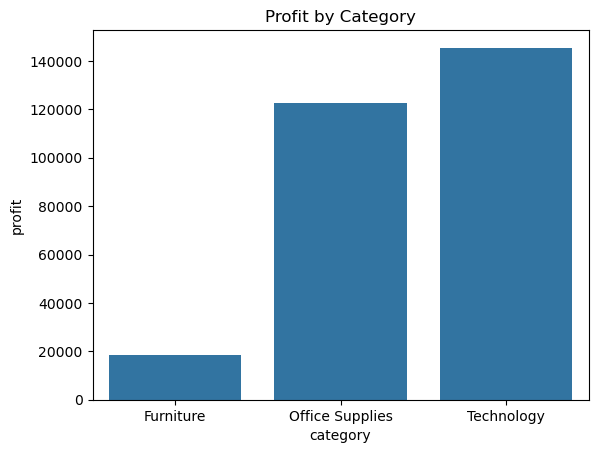

In [16]:
cat_profit=data.groupby('category')['profit'].sum().reset_index()
print(cat_profit)
sns.barplot(data=cat_profit, x='category', y='profit')
plt.title("Profit by Category")
plt.show()

In [17]:
furniture_evaluation=data[data['category']=='Furniture'].groupby('region')['profit'].sum().reset_index()
print(furniture_evaluation)

    region    profit
0  Central  -2871.10
1     East   3046.20
2    South   6771.23
3     West  11504.92


In [18]:
central_region_profits_and_losses=data[data['region']=='Central'].groupby('category')['profit'].sum().reset_index()
print(central_region_profits_and_losses)

          category    profit
0        Furniture  -2871.10
1  Office Supplies   8879.95
2       Technology  33697.60


In [19]:
discount_profits_effect_in_central=data[(data['region']=='Central') & (data['category']=='Furniture')].groupby('discount')['profit'].mean().reset_index()
print(discount_profits_effect_in_central)

   discount      profit
0      0.00  106.675577
1      0.30  -48.358662
2      0.32  -88.561481
3      0.50 -239.431111
4      0.60  -43.077101


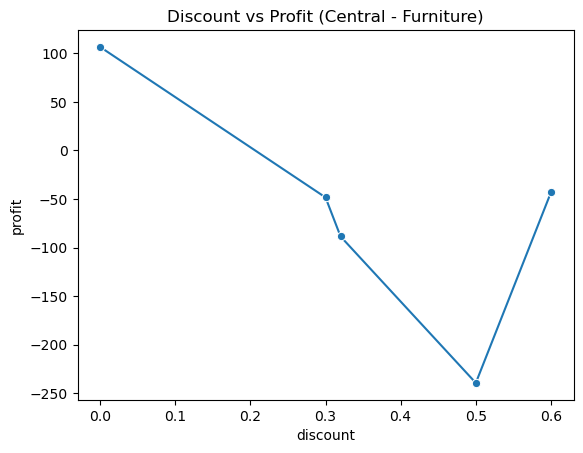

In [20]:
sns.lineplot(
    data=discount_profits_effect_in_central,
    x='discount',
    y='profit',
    marker='o'
)
plt.title("Discount vs Profit (Central - Furniture)")
plt.show()

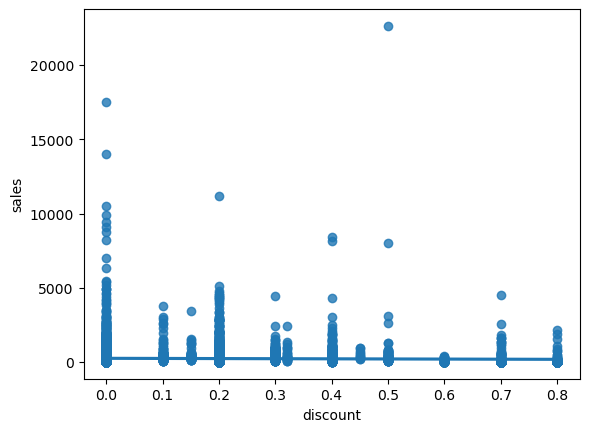

In [21]:
sns.regplot(data=data, x='discount', y='sales')
plt.show()